In [20]:
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd

df=pd.read_csv('datascience_salaries.csv')
print(df.head(10))

   Unnamed: 0       job_title   job_type experience_level  \
0           0  Data scientist  Full Time           Senior   
1           2  Data scientist  Full Time           Senior   
2           3  Data scientist  Full Time           Senior   
3           4  Data scientist  Full Time           Senior   
4           5  Data scientist  Full Time           Senior   
5           6  Data scientist  Full Time           Senior   
6           7  Data scientist  Full Time           Senior   
7           8  Data scientist  Full Time           Senior   
8           9  Data scientist  Full Time           Senior   
9          10  Data scientist  Full Time           Senior   

                 location salary_currency  salary  
0           New York City             USD  149000  
1                  Boston             USD  120000  
2                  London             USD   68000  
3                  Boston             USD  120000  
4           New York City             USD  149000  
5               

In [21]:
#Verifier s'il ya des doublons ou valeurs manquantes dans le dataset 
print("--------------------------------------------------------")
print(f" il ya {df.duplicated().sum()} doublons dans ce dataset")
missing_values_df=df.isna().sum()

missing_values_count=0
for element in missing_values_df:
    missing_values_count+=element

print("--------------------------------------------------------")
print(f" il ya {missing_values_count} valeurs manquante dans ce dataset")

--------------------------------------------------------
 il ya 0 doublons dans ce dataset
--------------------------------------------------------
 il ya 0 valeurs manquante dans ce dataset


   Unnamed: 0       job_title   job_type experience_level       location  \
0           0  Data scientist  Full Time           Senior  New York City   
1           2  Data scientist  Full Time           Senior         Boston   
2           3  Data scientist  Full Time           Senior         London   
3           4  Data scientist  Full Time           Senior         Boston   
4           5  Data scientist  Full Time           Senior  New York City   

  salary_currency  salary  
0             USD  149000  
1             USD  120000  
2             USD   68000  
3             USD  120000  
4             USD  149000  


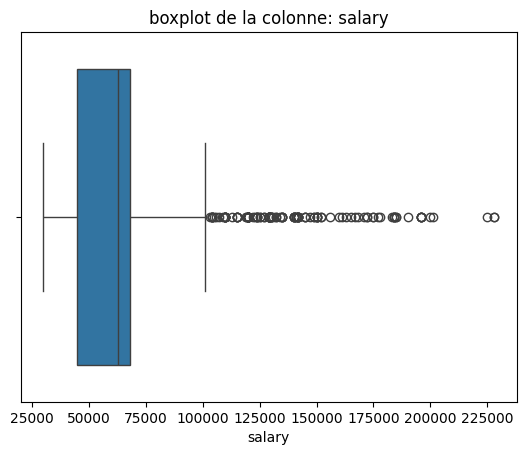

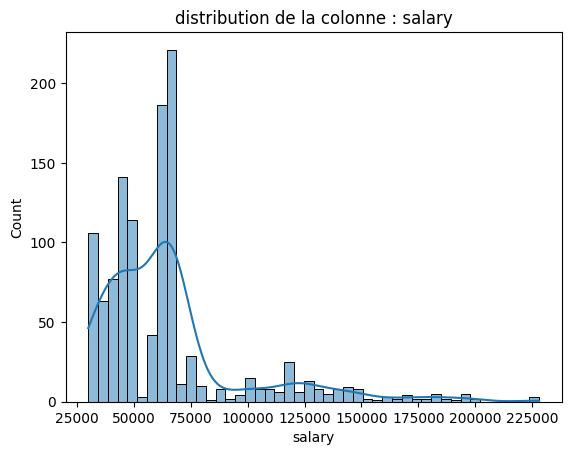

In [22]:
#verification de la présence d'outliers sur la base de boxplot 
print(df.head())
cleaned_df=df.drop(columns=['Unnamed: 0'])
numeric_columns=cleaned_df.select_dtypes(include=['number']).columns

for column in numeric_columns:
    plt.title(f"boxplot de la colonne: {column}")
    sns.boxplot(x=cleaned_df[column])
    plt.show()

#------------------------------------- voir la distribution de chaque colonne chiffrée

for column in numeric_columns:
    plt.title(f"distribution de la colonne : {column}")
    sns.histplot(x=cleaned_df[column],kde=True)

In [29]:
#Ici je vais encoder grace au one hot encoding la colonne experience_level pour pouvoir l'utiliser dans les modèles de machine learning
encoded_df=pd.get_dummies(cleaned_df,columns=['experience_level'])
print(encoded_df.head(10))
print(df.mean)

        job_title   job_type                location salary_currency  salary  \
0  Data scientist  Full Time           New York City             USD   63000   
1  Data scientist  Full Time                  Boston             USD   63000   
2  Data scientist  Full Time                  London             USD   68000   
3  Data scientist  Full Time                  Boston             USD   63000   
4  Data scientist  Full Time           New York City             USD   63000   
5  Data scientist  Full Time                  London             USD   68000   
6  Data scientist  Full Time  Research Triangle Park             USD   69000   
7  Data scientist  Full Time                  Sydney             USD   68000   
8  Data scientist  Full Time           San Francisco             USD   63000   
9  Data scientist  Full Time                   Sofia             USD   68000   

   experience_level_Entry  experience_level_Executive  experience_level_Mid  \
0                   False               

-------------------------------------
Q1: 45000.0
Q3: 68000.0
-------------------------------------
il ya 139 outliers dans la colonne salary
      Unnamed: 0       job_title    job_type experience_level  \
0              0  Data scientist   Full Time           Senior   
1              2  Data scientist   Full Time           Senior   
3              4  Data scientist   Full Time           Senior   
4              5  Data scientist   Full Time           Senior   
8              9  Data scientist   Full Time           Senior   
...          ...             ...         ...              ...   
1152        2188          ML Ops   Full Time              Mid   
1163        2237          ML Ops   Full Time           Senior   
1166        2243          ML Ops   Full Time           Senior   
1167        2249          ML Ops   Full Time           Senior   
1170        2259          ML Ops  Internship           Senior   

                          location salary_currency  salary  
0               

<Axes: title={'center': 'boxplot de la colonne salary'}, xlabel='salary'>

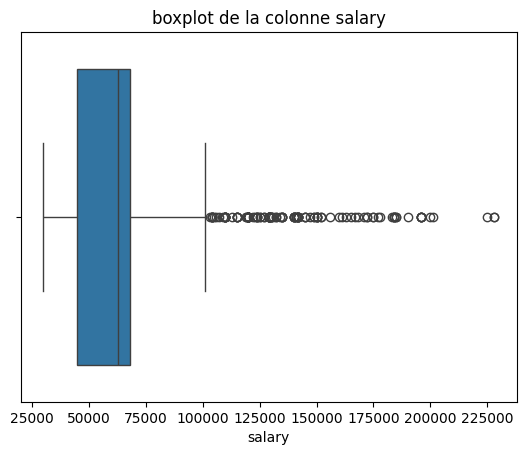

In [24]:
#Detection des outliers 
Q1=cleaned_df['salary'].quantile(0.25)
Q3=cleaned_df['salary'].quantile(0.75)

print("-------------------------------------")
print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print("-------------------------------------")

IQR=Q3-Q1

Upper_bound=Q3+1.5*IQR
Lower_bound=Q1-1.5*IQR
outliers=df[(df[column]<Lower_bound)|(df[column]>Upper_bound)] #On connait les outliers , il n'est pas recommandé de supprimer les outliers , on peut les traiter ou les remplacer par la moyenne ou la médiane

print(f"il ya {outliers.shape[0]} outliers dans la colonne salary")
print(outliers)

#Affichage d'un boxplot pour visualiser les outliers dans la colonne salary 
plt.title("boxplot de la colonne salary")
sns.boxplot(x=cleaned_df['salary'])

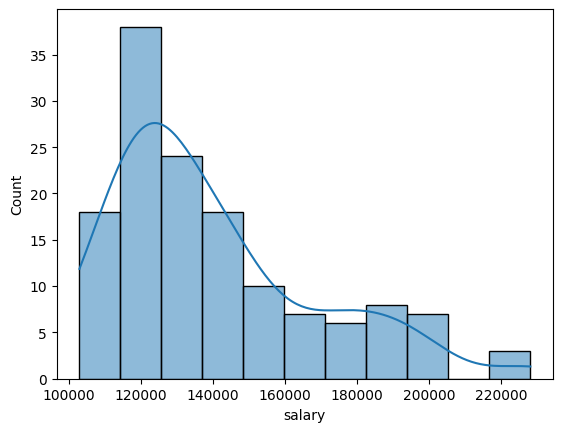

In [25]:
def outliers_distribution():
    sns.histplot(x=outliers['salary'],kde=True)


outliers_distribution()#il s'agit d'une distibution asymétrique. je vais les traiter en les remplacant par la médiane de la colonne history 

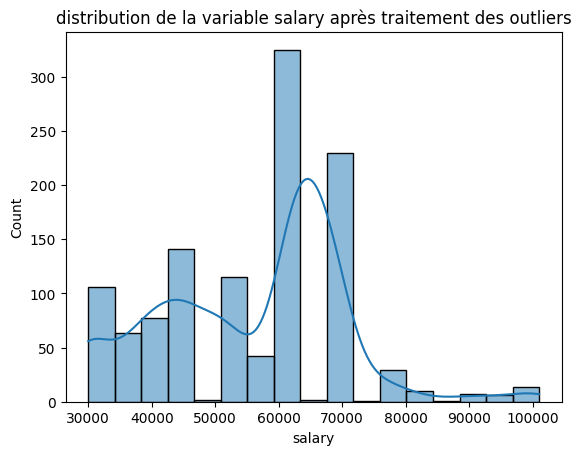

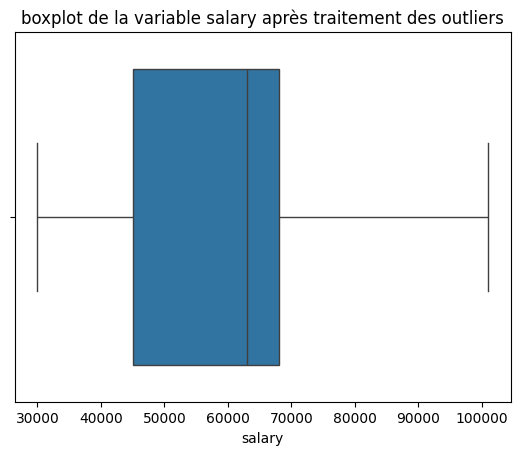

In [31]:
for index in outliers.index:
    cleaned_df.loc[index,'salary']=cleaned_df['salary'].median()
    encoded_df.loc[index,'salary']=encoded_df['salary'].median()
    

#cleaned df a maintenant une variable salary sans outliers.

#verification de la distribution de la variable salary après traitement sans outliers 
plt.title("distribution de la variable salary après traitement des outliers")
sns.histplot(x=cleaned_df['salary'],kde=True)
plt.show()

plt.title('boxplot de la variable salary après traitement des outliers')
sns.boxplot(x=cleaned_df['salary'])
plt.show()

        job_title   job_type       location salary_currency  salary  \
0  Data scientist  Full Time  New York City             USD   63000   
1  Data scientist  Full Time         Boston             USD   63000   
2  Data scientist  Full Time         London             USD   68000   
3  Data scientist  Full Time         Boston             USD   63000   
4  Data scientist  Full Time  New York City             USD   63000   

   experience_level_Entry  experience_level_Executive  experience_level_Mid  \
0                   False                       False                 False   
1                   False                       False                 False   
2                   False                       False                 False   
3                   False                       False                 False   
4                   False                       False                 False   

   experience_level_Senior  
0                     True  
1                     True  
2          

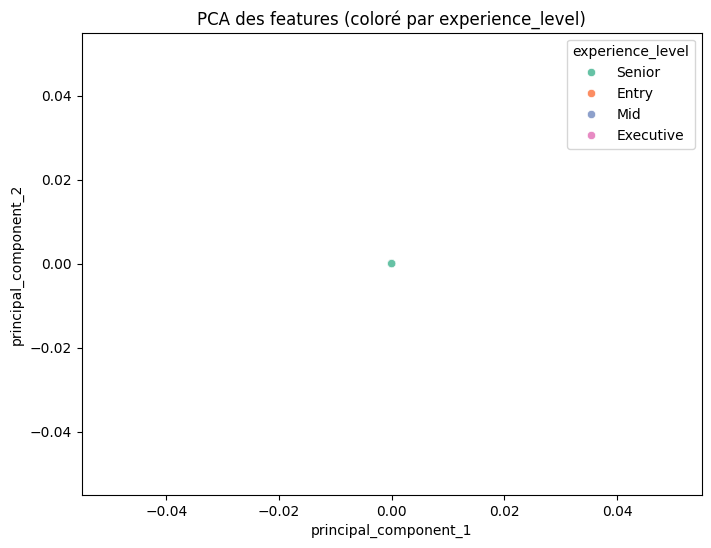

In [34]:
# Défensive: s'assurer que cleaned_df est une copie et que la colonne existe
cleaned_df = cleaned_df.copy()
if 'experience_level' not in cleaned_df.columns:
    raise KeyError("La colonne 'experience_level' est introuvable dans cleaned_df")

# One-hot encoding (si pas déjà fait)
encoded_df = pd.get_dummies(cleaned_df, columns=['experience_level'], drop_first=False)
print(encoded_df.head())

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

# Detection et traitement des outliers sur la colonne 'salary' (dans cleaned_df)
if 'salary' not in cleaned_df.columns:
    raise KeyError("La colonne 'salary' est introuvable dans cleaned_df")

Q1 = cleaned_df['salary'].quantile(0.25)
Q3 = cleaned_df['salary'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = cleaned_df[(cleaned_df['salary'] < lower_bound) | (cleaned_df['salary'] > upper_bound)]
print(f'Il y a {outliers.shape[0]} outliers dans la colonne salary')

# Remplacer les outliers par la médiane
median_salary = cleaned_df['salary'].median()
cleaned_df.loc[outliers.index, 'salary'] = median_salary
encoded_df.loc[outliers.index, 'salary'] = median_salary

# S'assurer qu'il n'y a pas de NaN sur salary avant normalisation
encoded_df['salary'] = encoded_df['salary'].fillna(median_salary)

# Normalisation Min-Max de la colonne 'salary' dans encoded_df
scaler = MinMaxScaler()
encoded_df['salary'] = scaler.fit_transform(encoded_df[['salary']])
print(encoded_df[['salary']].head())

# PCA sur les colonnes numériques (hors 'salary') avec garde-fous
numeric_cols = encoded_df.select_dtypes(include=['number']).columns.tolist()
numeric_cols_no_salary = [c for c in numeric_cols if c != 'salary']

if len(numeric_cols_no_salary) == 0:
    print('Aucune feature numérique (hors salary) pour faire la PCA. PCA ignorée.')
    pca_df = pd.DataFrame({'principal_component_1': [0]*len(encoded_df), 'principal_component_2': [0]*len(encoded_df)})
    pca_df['salary'] = encoded_df['salary'].values
else:
    n_features = len(numeric_cols_no_salary)
    n_components = min(2, n_features)
    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(encoded_df[numeric_cols_no_salary])
    cols = [f'pc{i+1}' for i in range(n_components)]
    pca_df = pd.DataFrame(pca_result, columns=cols)
    if n_components == 1:
        pca_df['pc2'] = 0.0
    pca_df.rename(columns={'pc1':'principal_component_1','pc2':'principal_component_2'}, inplace=True)
    pca_df['salary'] = encoded_df['salary'].values

print(pca_df.head())

# Regrouper par niveau d'expérience et calculer mean/median du salaire (sur cleaned_df)
grouped_df = cleaned_df.groupby('experience_level').agg({'salary':['mean','median']})
print(grouped_df)

# Visualisation: PCA colorée par niveau d'expérience (si disponible)
import matplotlib.pyplot as plt
import seaborn as sns
pca_df['experience_level'] = cleaned_df['experience_level'].values
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='principal_component_1', y='principal_component_2', hue='experience_level', palette='Set2')
plt.title('PCA des features (coloré par experience_level)')
plt.show()
